# 1.3 Statistik & Wahrscheinlichkeit — Lösung

Begleit-Notebook zu **Lektion 1.3**: Kennzahlen, Verteilungen, Simulationen und eine erste Maximum-Likelihood-Schätzung.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
rng = np.random.default_rng(42)

## 1. Kennzahlen selbst implementieren

In [2]:
def mittelwert(x):
    # Summe / Anzahl
    return x.sum() / len(x)

def varianz(x, ddof=0):
    # mittlere quadrierte Abweichung; ddof=1 teilt durch n-1
    return ((x - mittelwert(x)) ** 2).sum() / (len(x) - ddof)

def median(x):
    # sortieren, mittleres Element (bei gerader Anzahl: Mittel der beiden mittleren)
    s = np.sort(x)
    n = len(s)
    return s[n // 2] if n % 2 else (s[n // 2 - 1] + s[n // 2]) / 2

x = rng.normal(10, 2, size=1001)
print(mittelwert(x), np.mean(x))
print(varianz(x), np.var(x), varianz(x, ddof=1), np.var(x, ddof=1))
print(median(x), np.median(x))

9.942156176539514 9.942156176539514
3.906384890136982 3.906384890136982 3.910291275027119 3.910291275027119
10.012033360872143 10.012033360872143


**Aufgabe 1.2:** Füge den Gehältern einen Ausreißer hinzu und beobachte, wie stark sich Mittelwert und Median ändern.

In [3]:
gehaelter = np.array([42, 45, 47, 50, 51, 53, 55, 58, 60], dtype=float)  # in T€
# Hänge ein Gehalt von 1000 T€ an und vergleiche Mittelwert und Median vorher/nachher
mit_chefin = np.append(gehaelter, 1000.0)
print(f"vorher:  Mittelwert {mittelwert(gehaelter):7.1f}   Median {median(gehaelter):5.1f}")
print(f"nachher: Mittelwert {mittelwert(mit_chefin):7.1f}   Median {median(mit_chefin):5.1f}")

vorher:  Mittelwert    51.2   Median  51.0
nachher: Mittelwert   146.1   Median  52.0


## 2. z-Scores und Ausreißer

**Aufgabe 2.1:** Berechne die z-Scores und finde alle Werte mit $|z| > 3$.

In [4]:
messwerte = np.r_[rng.normal(50, 5, size=500), [85, 12, 90]]
# z-Scores und Indizes der Ausreißer
z = (messwerte - messwerte.mean()) / messwerte.std()
ausreisser = np.where(np.abs(z) > 3)[0]
print("Ausreißer:", messwerte[ausreisser])

Ausreißer: [85. 12. 90.]


## 3. Zentraler Grenzwertsatz

Wir ziehen viele Stichproben aus einer **sehr schiefen** Verteilung (Exponentialverteilung) und schauen uns die Verteilung der Mittelwerte an.

**Aufgabe 3.1:** Für jedes `n` in `[1, 2, 10, 50]`: Ziehe 10 000 Stichproben der Größe `n` und berechne jeweils den Mittelwert.
Ergänze außerdem die theoretische Standardabweichung des Mittelwerts $\sigma/\sqrt{n}$ (hier ist $\sigma = 1$).

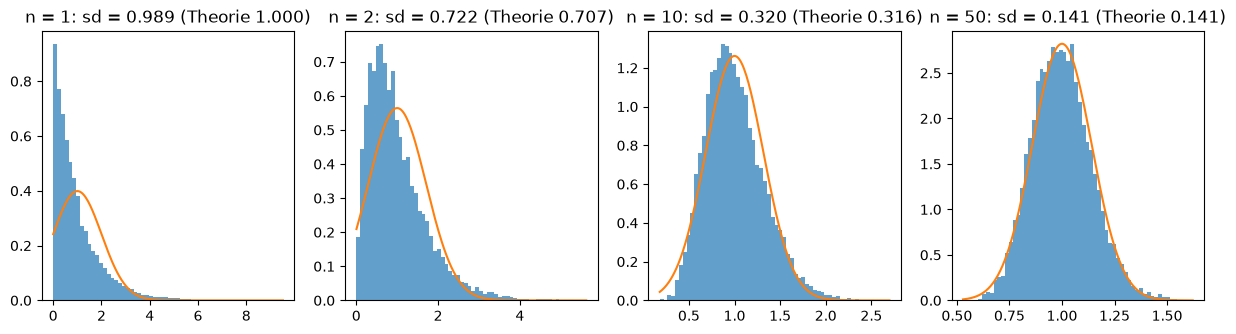

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, n in zip(axes, [1, 2, 10, 50]):
    # 10 000 Mittelwerte von je n exponentialverteilten Zahlen (rng.exponential(1.0, size=(10_000, n)))
    mittelwerte = rng.exponential(1.0, size=(10_000, n)).mean(axis=1)
    # theoretische Standardabweichung des Mittelwerts
    sd_theorie = 1.0 / np.sqrt(n)
    ax.hist(mittelwerte, bins=60, density=True, alpha=0.7)
    t = np.linspace(mittelwerte.min(), mittelwerte.max(), 200)
    ax.plot(t, np.exp(-(t - 1) ** 2 / (2 * sd_theorie**2)) / (sd_theorie * np.sqrt(2 * np.pi)))
    ax.set_title(f"n = {n}: sd = {mittelwerte.std():.3f} (Theorie {sd_theorie:.3f})")
plt.show()

## 4. Satz von Bayes durch Simulation

Statt die Formel anzuwenden, simulieren wir 1 000 000 Personen. **Aufgabe 4.1:** Ergänze die Simulation und vergleiche mit der Formel.

In [6]:
N = 1_000_000
praevalenz, sensitivitaet, spezifitaet = 0.01, 0.95, 0.95

krank = rng.random(N) < praevalenz
# Testergebnis simulieren: Kranke sind mit Wahrscheinlichkeit 'sensitivitaet' positiv,
# Gesunde mit Wahrscheinlichkeit 1 - spezifitaet
zufall = rng.random(N)
positiv = np.where(krank, zufall < sensitivitaet, zufall < 1 - spezifitaet)
# P(krank | positiv) aus der Simulation und aus der Bayes-Formel
p_sim = krank[positiv].mean()
p_formel = sensitivitaet * praevalenz / (sensitivitaet * praevalenz + (1 - spezifitaet) * (1 - praevalenz))
print(f"Simulation: {p_sim:.4f}   Formel: {p_formel:.4f}")

Simulation: 0.1584   Formel: 0.1610


## 5. Korrelation

**Aufgabe 5.1:** Implementiere den Pearson-Korrelationskoeffizienten und teste ihn an drei Fällen: linear, verrauscht, quadratisch.

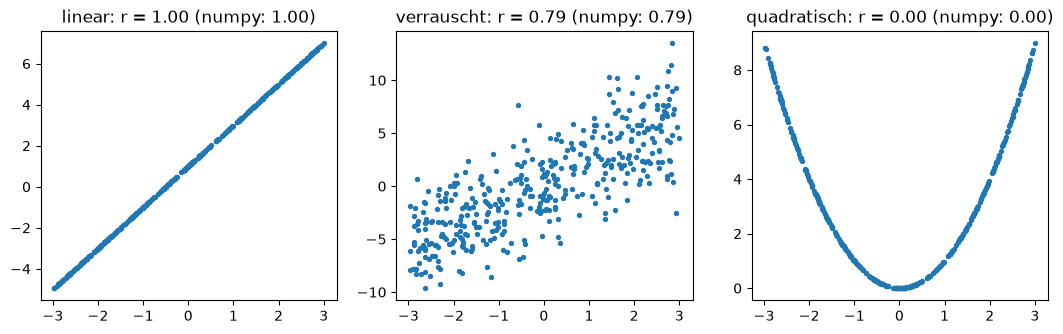

In [7]:
def pearson(x, y):
    # Kovarianz / (sd_x * sd_y)
    xc, yc = x - x.mean(), y - y.mean()
    return (xc @ yc) / np.sqrt((xc @ xc) * (yc @ yc))

x = rng.uniform(-3, 3, 400)
faelle = {"linear": 2 * x + 1, "verrauscht": 2 * x + rng.normal(0, 3, 400), "quadratisch": x**2}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, y) in zip(axes, faelle.items()):
    ax.scatter(x, y, s=8)
    ax.set_title(f"{name}: r = {pearson(x, y):.2f} (numpy: {np.corrcoef(x, y)[0, 1]:.2f})")
plt.show()

## 6. Maximum Likelihood

Wir haben Daten aus einer Normalverteilung mit unbekanntem Mittelwert $\mu$ (Standardabweichung 1 sei bekannt).
Die negative Log-Likelihood ist bis auf Konstanten

$$\mathrm{NLL}(\mu) = \frac{1}{2}\sum_i (x_i - \mu)^2 .$$

**Aufgabe 6.1:** Berechne die NLL für viele Kandidaten $\mu$ und finde das Minimum. Vergleiche mit dem Stichprobenmittelwert.

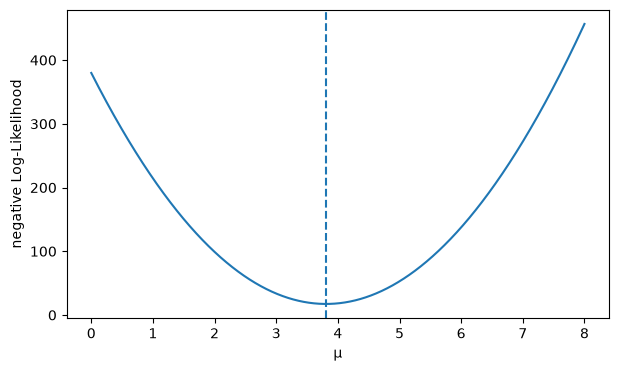

MLE: 3.808   Stichprobenmittelwert: 3.808


In [8]:
daten = rng.normal(3.7, 1.0, size=50)
kandidaten = np.linspace(0, 8, 2001)
# NLL für jeden Kandidaten (vektorisiert: kandidaten[:, None] - daten[None, :])
nll = 0.5 * ((daten[None, :] - kandidaten[:, None]) ** 2).sum(axis=1)
mu_mle = kandidaten[np.argmin(nll)]
plt.plot(kandidaten, nll); plt.axvline(mu_mle, ls="--")
plt.xlabel("μ"); plt.ylabel("negative Log-Likelihood"); plt.show()
print(f"MLE: {mu_mle:.3f}   Stichprobenmittelwert: {daten.mean():.3f}")

Die MLE ist genau der Mittelwert – und die NLL ist (bis auf den Faktor) der **quadratische Fehler**.
Das ist der Grund, warum MSE für Regression so natürlich ist (Lektion 5).